Load and inspect the dataset

Read the CSV, check shape, data types, and the label distribution to confirm everything loaded correctly.

In [2]:
import pandas as pd
import numpy as np
import io
import os

# read the raw bytes of the zip file
with open(r'C:\Users\rageg\OneDrive\Desktop\ML Project\DDOS_Dataset.csv', 'rb') as f:
    raw = f.read()

# pandas can read zip files directly using compression parameter
df = pd.read_csv(
    r'C:\Users\rageg\OneDrive\Desktop\ML Project\DDOS_Dataset.csv',
    compression='zip'
)

print(df.shape)
print(df.head())
print(df['label'].value_counts())
print(df.isnull().sum()) # check missing values

(104345, 23)
      dt  switch       src       dst  pktcount  bytecount  dur   dur_nsec  \
0  11425       1  10.0.0.1  10.0.0.8     45304   48294064  100  716000000   
1  11605       1  10.0.0.1  10.0.0.8    126395  134737070  280  734000000   
2  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   
3  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   
4  11425       1  10.0.0.2  10.0.0.8     90333   96294978  200  744000000   

        tot_dur  flows  ...  pktrate  Pairflow  Protocol  port_no   tx_bytes  \
0  1.010000e+11      3  ...      451         0       UDP        3  143928631   
1  2.810000e+11      2  ...      451         0       UDP        4       3842   
2  2.010000e+11      3  ...      451         0       UDP        1       3795   
3  2.010000e+11      3  ...      451         0       UDP        2       3688   
4  2.010000e+11      3  ...      451         0       UDP        3       3413   

  rx_bytes  tx_kbps  rx_kbps  tot_kbps  lab

Handle missing values

Your dataset has 506 missing values in rx_kbps and tot_kbps. Fill them with the column median — a safe choice for skewed network traffic data.

In [3]:
df['rx_kbps'].fillna(df['rx_kbps'].median())
df['tot_kbps'].fillna(df['tot_kbps'].median())

print(df.isnull().sum().sum())  # should print 0

1012


FEATURE ENGINEERING

In [4]:
# Ratio features — capture relationships between raw counts
df['bytes_per_packet'] = df['bytecount'] / (df['pktcount'] + 1)
df['tx_rx_ratio']      = df['tx_bytes']  / (df['rx_bytes'] + 1)
df['kbps_per_flow']    = df['tot_kbps']  / (df['flows'] + 1)
df['pkt_per_second']   = df['pktcount']  / (df['tot_dur'] + 1)

# Interaction features — combinations that together signal attacks
df['rate_x_flows']      = df['pktrate']   * df['flows']
df['bandwidth_x_pkts']  = df['tot_kbps']  * df['pktcount']
df['packetins_x_flows'] = df['packetins'] * df['flows']

# Confirm new features were added
print(f"New shape: {df.shape}")     # should show 23 + 7 = 30 columns
print("New columns added:")
print([c for c in df.columns if c not in [
    'dt','switch','src','dst','pktcount','bytecount','dur',
    'dur_nsec','tot_dur','flows','packetins','pktperflow',
    'byteperflow','pktrate','Pairflow','Protocol','port_no',
    'tx_bytes','rx_bytes','tx_kbps','rx_kbps','tot_kbps','label'
]])

New shape: (104345, 30)
New columns added:
['bytes_per_packet', 'tx_rx_ratio', 'kbps_per_flow', 'pkt_per_second', 'rate_x_flows', 'bandwidth_x_pkts', 'packetins_x_flows']


Encode categorical features

Three columns are non-numeric: src, dst, and Protocol. Encode them so the model can use them.

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['src']      = le.fit_transform(df['src'].astype(str))
df['dst']      = le.fit_transform(df['dst'].astype(str))
df['Protocol'] = le.fit_transform(df['Protocol'].astype(str))

print(df[['src','dst','Protocol']].head())

   src  dst  Protocol
0    0   16         2
1    0   16         2
2   10   16         2
3   10   16         2
4   10   16         2


Split features and target, then train/test split

Separate X (features) from y (label), then split into 80% training and 20% test set. Stratify to preserve the class ratio in both sets.

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps 61/39 ratio in both splits
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (83476, 29), Test: (20869, 29)


No feature scaling needed

Decision Trees split data using thresholds on individual features. The actual scale of values doesn't affect which threshold is chosen, so StandardScaler is not required.

In [7]:
# Decision Tree does NOT need scaling
# Use raw X_train and X_test directly — no StandardScaler

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


X_train shape: (83476, 29)
X_test shape : (20869, 29)


Train the Decision Tree model

Initialize with max_depth=6 to prevent the tree from growing too deep and overfitting. A fully grown tree will memorize training data perfectly but fail on new data.

In [8]:
from sklearn.tree import DecisionTreeClassifier
import time

dt_model = DecisionTreeClassifier(
    max_depth=6,        # limits tree depth — prevents overfitting
    random_state=42,
    criterion='gini'    # gini impurity to measure split quality
)

start = time.time()
dt_model.fit(X_train, y_train)   # no scaling needed
print(f"Training time: {time.time() - start:.2f}s")

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

Training time: 0.51s


Calculate all performance metrics

Same metrics as Logistic Regression — accuracy, precision, recall, F1, ROC-AUC, and confusion matrix.

In [9]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

print("=== Decision Tree Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt,
      target_names=['Normal', 'DDoS']))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

=== Decision Tree Results ===
Accuracy : 0.9840
ROC-AUC  : 0.9950

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     12712
        DDoS       0.96      1.00      0.98      8157

    accuracy                           0.98     20869
   macro avg       0.98      0.99      0.98     20869
weighted avg       0.98      0.98      0.98     20869


Confusion Matrix:
[[12396   316]
 [   17  8140]]


Plot confusion matrix and ROC curve

Same plots as Logistic Regression, just using Decision Tree predictions.

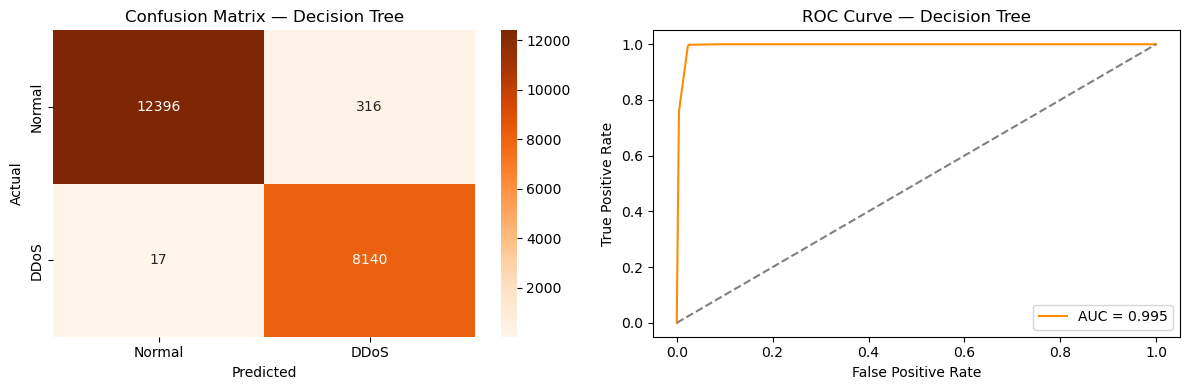

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'DDoS'],
            yticklabels=['Normal', 'DDoS'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Decision Tree')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
auc = roc_auc_score(y_test, y_prob_dt)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='darkorange')
axes[1].plot([0,1], [0,1], '--', color='gray')
axes[1].set_title('ROC Curve — Decision Tree')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('dt_evaluation.png', dpi=150)
plt.show()

Plot feature importance + visualize the tree

Decision Tree gives you two unique visuals — a feature importance bar chart and an actual visualization of the tree structure showing decision rules.

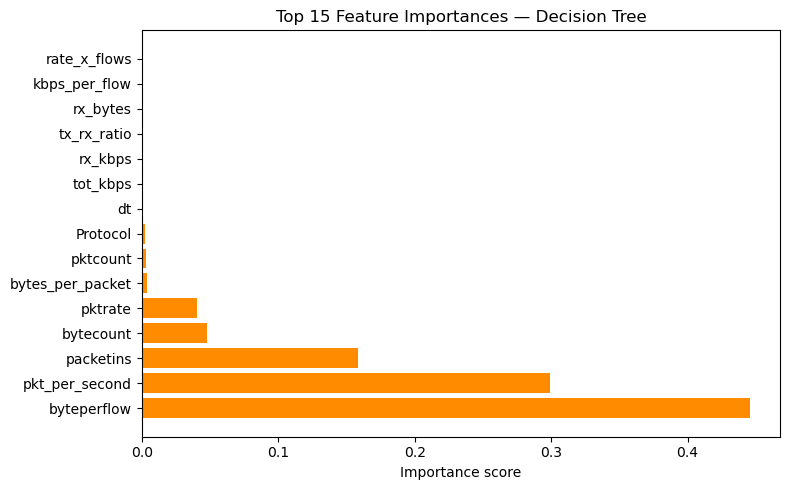

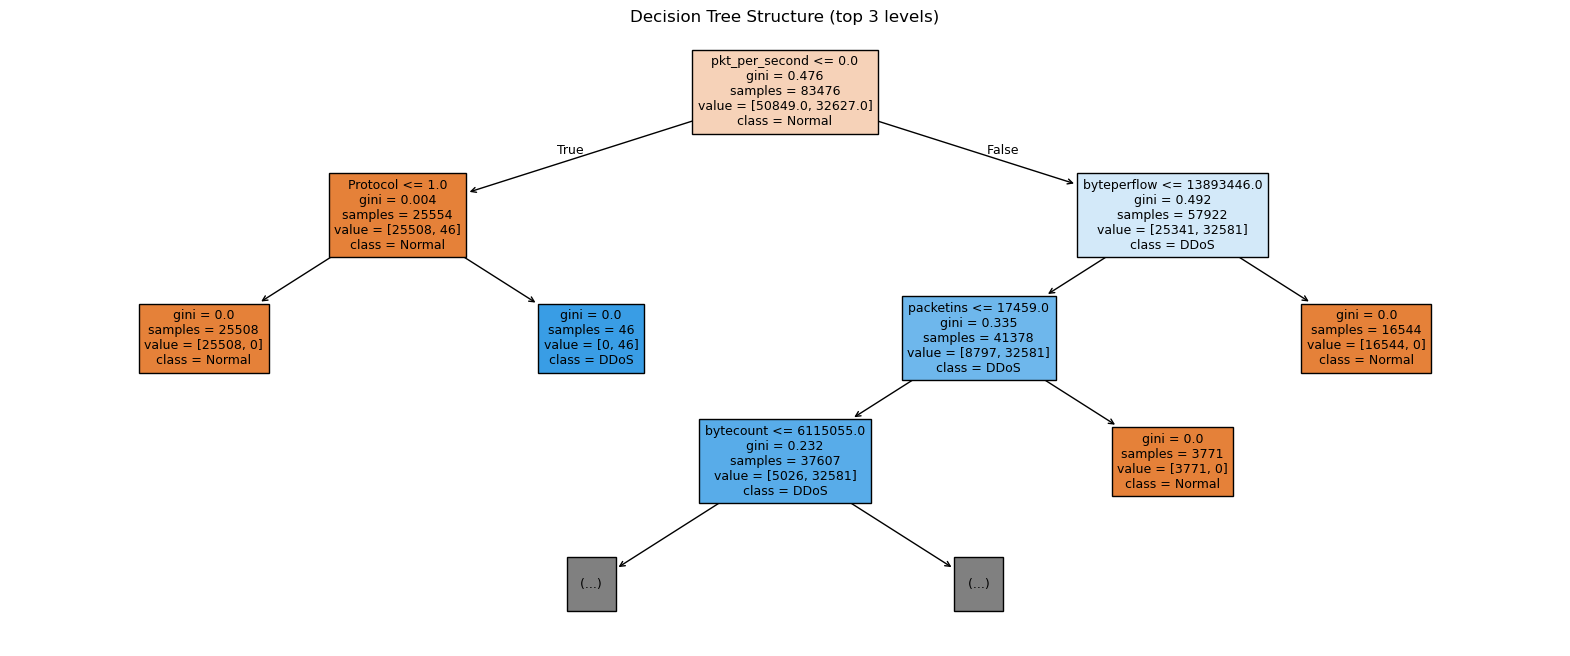

In [11]:
from sklearn.tree import plot_tree

# Feature importance
feat_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='darkorange')
plt.title('Top 15 Feature Importances — Decision Tree')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150)
plt.show()

# Tree structure (first 3 levels only — full tree is huge)
plt.figure(figsize=(20, 8))
plot_tree(dt_model,
          max_depth=3,               # show top 3 levels only
          feature_names=list(X_train.columns),
          class_names=['Normal', 'DDoS'],
          filled=True,
          fontsize=9)
plt.title('Decision Tree Structure (top 3 levels)')
plt.savefig('dt_structure.png', dpi=150, bbox_inches='tight')
plt.show()

Store metrics for final comparison

Add Decision Tree results to the same results dictionary you created in Logistic Regression step 10.

In [13]:
results = {}
report_dt = classification_report(y_test, y_pred_dt,
               output_dict=True)

results['Decision Tree'] = {
    'accuracy' : accuracy_score(y_test, y_pred_dt),
    'roc_auc'  : roc_auc_score(y_test, y_prob_dt),
    'precision': report_dt['1']['precision'],
    'recall'   : report_dt['1']['recall'],
    'f1'       : report_dt['1']['f1-score'],
}

print(pd.DataFrame(results).T)

               accuracy   roc_auc  precision    recall        f1
Decision Tree  0.984043  0.994959    0.96263  0.997916  0.979955
